# Understanding and mapping the Global Human Settlement Layer

1. Extract settlement extent from [UCDB](https://human-settlement.emergency.copernicus.eu/ghs_ucdb_2024.php)  
2. Clip out ghsl layers for selected area  
3. Convert ghsl layers to "year of built" layer (GOSTrocks.ghslmisc function) 
4. ...  
5. Profit  


In [1]:
import sys, os
import rasterio

import geopandas as gpd
import pandas as pd

sys.path.insert(0, "../src")

import GOSTrocks.ghslMisc as ghslMisc
import GOSTrocks.rasterMisc as rMisc
import GOSTrocks.mapMisc as mapMisc

%load_ext autoreload
%autoreload 2

In [2]:
ucdb_path = r'C:\WBG\Work\data\URBAN\GHS_UCDB_GLOBE_R2024A.gpkg'
ghsl_folder = r'C:\WBG\Work\data\GHSL\BUILT'
ghsl_files = [os.path.join(ghsl_folder, f) for f in os.listdir(ghsl_folder) if f.endswith('.tif')]
out_folder = r'C:\WBG\Work\Projects\SDG_ATLAS\Urban'
if not os.path.exists(out_folder):
    os.makedirs(out_folder)

# gpd.list_layers(ucdb_path)
in_ucdb = gpd.read_file(ucdb_path, layer="GHS_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A")
in_ucdb.head()


,ID_UC_G0,GC_UCN_MAI_2025,GC_UCN_LIS_2025,GC_CNT_GAD_2025,GC_CNT_UNN_2025,GC_UCA_KM2_2025,GC_POP_TOT_2025,GC_DEV_WIG_2025,GC_DEV_USR_2025,GC_PLS_SCR_2025,GC_UCB_YOB_2025,GC_UCB_YOD_2025,GC_UCM_CAP,geometry
0,1,Apia,Apia,Samoa,Samoa,35,60041.65661,Lower Middle,Oceania,High,2025,2030,1,"MULTIPOLYGON (((-16906000 -1703000, -16905000 ..."
1,2,Nuku'alofa,Nuku'alofa,Tonga,Tonga,20,51990.76620,Upper Middle,Oceania,High,2025,2030,1,"MULTIPOLYGON (((-16819000 -2590000, -16817000 ..."
2,3,Ewa Beach,Ewa Beach,United States,United States of America,15,53720.65818,High income,Northern America,High,2025,2030,0,"MULTIPOLYGON (((-15157000 2615000, -15156000 2..."
3,4,Papeete,Papeete,French Polynesia,French Polynesia,50,109747.12570,High income,Oceania,High,1980,2030,1,"MULTIPOLYGON (((-14552000 -2155000, -14551000 ..."
4,5,Rosarito,Rosarito,México,Mexico,29,76707.05999,Upper Middle,Latin America and the Caribbean,High,2015,2030,0,"MULTIPOLYGON (((-10562000 3925000, -10560000 3..."


09:43:02	*** 0 completed 1975
09:43:02	*** 1 completed 1980
09:43:02	*** 2 completed 1985
09:43:02	*** 3 completed 1990
09:43:02	*** 4 completed 1995
09:43:02	*** 5 completed 2000
09:43:02	*** 6 completed 2005
09:43:03	*** 7 completed 2010
09:43:03	*** 8 completed 2015
09:43:03	*** 9 completed 2020
09:43:03	*** 10 completed 2025


c:\WBG\Work\Code\GOSTrocks\notebooks\../src\GOSTrocks\ghslMisc.py:54: RuntimeWarning: All-NaN slice encountered
  ghsl_final = np.nanmin(all_ghsl, axis=2)
c:\WBG\Work\Code\GOSTrocks\notebooks\../src\GOSTrocks\ghslMisc.py:56: RuntimeWarning: invalid value encountered in cast
  ghsl_int = ghsl_final.astype(int)


09:43:04	*** 0 completed 1975
09:43:04	*** 1 completed 1980
09:43:04	*** 2 completed 1985
09:43:04	*** 3 completed 1990
09:43:04	*** 4 completed 1995
09:43:04	*** 5 completed 2000
09:43:04	*** 6 completed 2005
09:43:04	*** 7 completed 2010
09:43:04	*** 8 completed 2015
09:43:04	*** 9 completed 2020
09:43:04	*** 10 completed 2025


c:\WBG\Work\Code\GOSTrocks\notebooks\../src\GOSTrocks\ghslMisc.py:54: RuntimeWarning: All-NaN slice encountered
  ghsl_final = np.nanmin(all_ghsl, axis=2)
c:\WBG\Work\Code\GOSTrocks\notebooks\../src\GOSTrocks\ghslMisc.py:56: RuntimeWarning: invalid value encountered in cast
  ghsl_int = ghsl_final.astype(int)


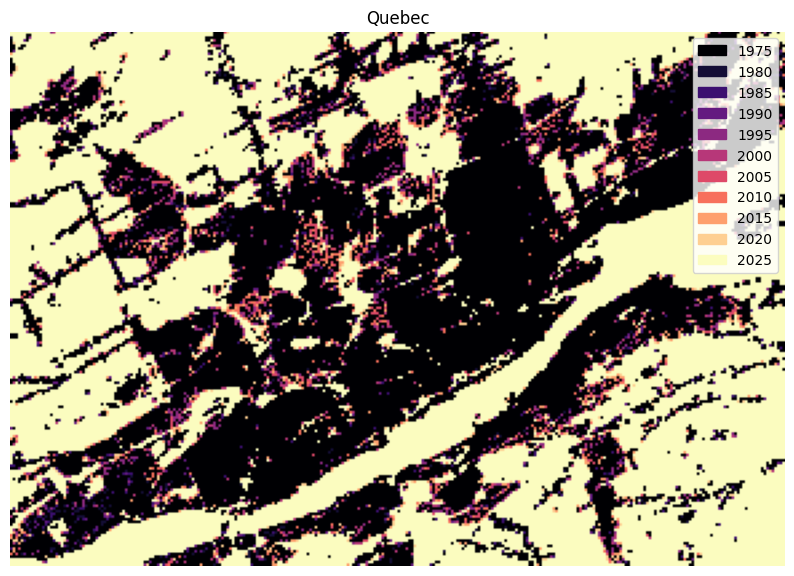

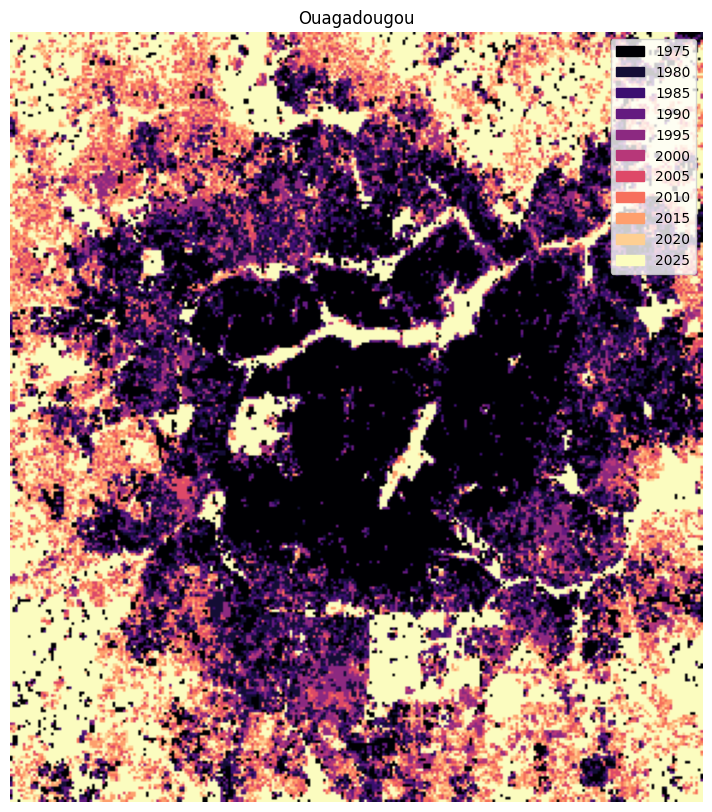

In [3]:
cities = ['Quebec', "Ouagadougou"]
for cur_city in cities:
    temp_out_folder = os.path.join(out_folder, cur_city)
    if not os.path.exists(temp_out_folder):
        os.makedirs(temp_out_folder)

    cur_city_ucdb = in_ucdb.loc[in_ucdb['GC_UCN_MAI_2025'] == cur_city].copy()
    combined_ghsl_file = os.path.join(temp_out_folder, f"{cur_city}_combined_ghsl.tif")
    map_file = os.path.join(temp_out_folder, f"{cur_city}_map.png")    
    out_ghsl_files = []
    for ghsl_file in ghsl_files:
        cur_out_file = os.path.join(temp_out_folder, os.path.basename(ghsl_file))
        out_ghsl_files.append(cur_out_file)
        with rasterio.open(ghsl_file) as src:
            rMisc.clipRaster(src, cur_city_ucdb, cur_out_file, crop=False)

    ghslMisc.combine_ghsl_annual(out_ghsl_files, out_file=combined_ghsl_file)
    plt, fig, ax = mapMisc.static_map_raster(rasterio.open(combined_ghsl_file), thresh=list(range(1975, 2026, 5)))
    ax.set_title(cur_city)
    ax.set_axis_off()
    plt.savefig(map_file, bbox_inches='tight', dpi=300)

    


In [4]:
rasterio.open(combined_ghsl_file).meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 65535.0,
 'width': 270,
 'height': 300,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(100.0, 0.0, -165000.0,
        0.0, -100.0, 1539000.0)}